In [3]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless opencv-contrib-python-headless
!pip install opencv-contrib-python

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 MB 9.5 MB/s eta 0:00:00


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)

hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

print("HOG initialized successfully!")

OpenCV version: 5.0.0
HOG initialized successfully!


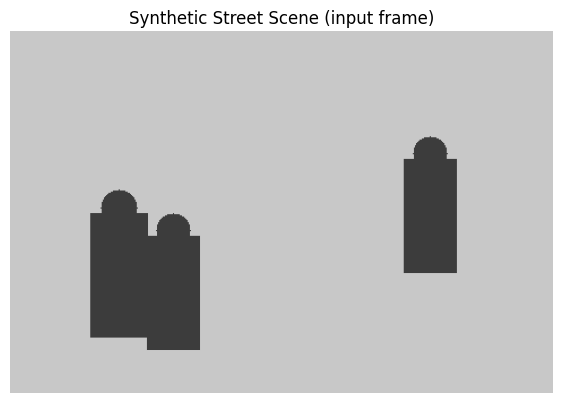

In [2]:
def make_synthetic_street_scene(width=480, height=320, n_people=3, seed=42):
    """Builds a simple synthetic 'street scene' with person-shaped silhouettes,
    used here as a stand-in for a real street/CCTV frame."""
    rng = np.random.RandomState(seed)
    img = np.full((height, width, 3), 200, dtype=np.uint8)  # light gray background

    boxes = []
    for _ in range(n_people):
        w = rng.randint(40, 60)
        h = int(w * 2.6)
        x = rng.randint(0, width - w)
        y = rng.randint(height // 4, height - h)
        # body (rectangle) + head (circle) silhouette
        cv2.rectangle(img, (x, y + h // 6), (x + w, y + h), (60, 60, 60), -1)
        cv2.circle(img, (x + w // 2, y + h // 8), w // 3, (60, 60, 60), -1)
        boxes.append((x, y, w, h))
    return img, boxes

frame, gt_boxes = make_synthetic_street_scene()
plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Synthetic Street Scene (input frame)")
plt.axis("off")
plt.show()

In [3]:
# Run HOG + SVM pedestrian detection
rects, weights = hog.detectMultiScale(
    frame, winStride=(4, 4), padding=(8, 8), scale=1.05
)

print(f"Detections found: {len(rects)}")
for (x, y, w, h), conf in zip(rects, weights):
    print(f"  box=({x},{y},{w},{h})  confidence={conf[0]:.2f}")

Detections found: 0


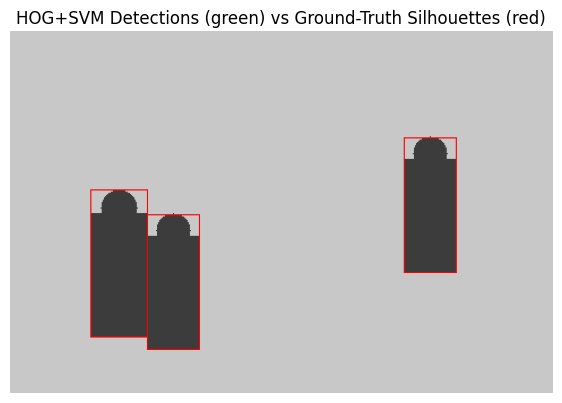

In [4]:
detected = frame.copy()
for (x, y, w, h) in rects:
    cv2.rectangle(detected, (x, y), (x + w, y + h), (0, 255, 0), 2)

for (x, y, w, h) in gt_boxes:
    cv2.rectangle(detected, (x, y), (x + w, y + h), (0, 0, 255), 1)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB))
plt.title("HOG+SVM Detections (green) vs Ground-Truth Silhouettes (red)")
plt.axis("off")
plt.show()

In [5]:
# Note for real-world use:
# Replace `frame` above with cv2.imread('your_street_image.jpg') or a video frame
# captured via cv2.VideoCapture(0) to run this on real pedestrian footage.
# The HOG+SVM pipeline (detectMultiScale) works identically on real images —
# only the input source changes.
print("Pipeline ready — swap the synthetic frame for a real image/video frame to use on live data.")

Pipeline ready — swap the synthetic frame for a real image/video frame to use on live data.
